## Setup & Data Splitting

In [1]:
import os
import shutil
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub

# Set seeds for reproducibility
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

print("Downloading GTZAN Dataset...")
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
source_dir = os.path.join(path, 'Data', 'genres_original')
target_root = 'gtzan_audio_split'

if not os.path.exists(target_root):
    print("Building strict isolated directories to prevent data leakage...")
    genres = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

    for split in ['train', 'val', 'test']:
        for genre in genres:
            os.makedirs(os.path.join(target_root, split, genre), exist_ok=True)

    for genre in genres:
        genre_path = os.path.join(source_dir, genre)
        files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
        if 'jazz.00054.wav' in files: files.remove('jazz.00054.wav')

        random.shuffle(files)
        train_idx, val_idx = int(len(files) * 0.8), int(len(files) * 0.9)

        splits = {
            'train': files[:train_idx],
            'val': files[train_idx:val_idx],
            'test': files[val_idx:]
        }

        for split, split_files in splits.items():
            for f in split_files:
                shutil.copy(os.path.join(genre_path, f), os.path.join(target_root, split, genre, f))
    print("Data successfully downloaded and split!")
else:
    print("Split directories already exist. Skipping split phase.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Building strict isolated directories to prevent data leakage...
Data successfully downloaded and split!
Active Device: cuda


## Data Processing & Loaders

In [2]:
class GTZAN_3Second_Dataset(Dataset):
    def __init__(self, root_dir, split, sample_rate=22050, duration=3, augment=False):
        self.root_dir = os.path.join(root_dir, split)
        self.sample_rate = sample_rate
        self.n_samples = sample_rate * duration
        self.augment = augment
        self.file_list = []

        genres = sorted(os.listdir(self.root_dir))
        self.label_to_idx = {genre: i for i, genre in enumerate(genres)}

        for genre in genres:
            genre_dir = os.path.join(self.root_dir, genre)
            for f in os.listdir(genre_dir):
                if f.endswith('.wav'):
                    full_path = os.path.join(genre_dir, f)
                    for segment_idx in range(10):
                        self.file_list.append((full_path, self.label_to_idx[genre], segment_idx))

        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate, n_fft=2048, hop_length=512, n_mels=128
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)
        self.pitch_shift = torchaudio.transforms.PitchShift(sample_rate, n_steps=2)

    def add_white_noise(self, waveform, noise_level=0.005):
        return waveform + (torch.randn_like(waveform) * noise_level)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path, label, segment_idx = self.file_list[idx]
        offset = segment_idx * self.n_samples

        try:
            waveform, sr = torchaudio.load(path, frame_offset=offset, num_frames=self.n_samples)
            if waveform.numel() == 0 or waveform.shape[1] == 0:
                waveform, sr = torch.zeros((1, self.n_samples)), self.sample_rate
        except Exception:
            waveform, sr = torch.zeros((1, self.n_samples)), self.sample_rate

        if sr != self.sample_rate:
            waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.sample_rate)(waveform)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        if self.augment:
            if random.random() > 0.5: waveform = self.pitch_shift(waveform)
            if random.random() > 0.5: waveform = self.add_white_noise(waveform)

        mel_spec = self.mel_spectrogram(waveform)
        mel_spec_db = self.amplitude_to_db(mel_spec)

        target_frames = 130
        if mel_spec_db.shape[2] < target_frames:
            mel_spec_db = F.pad(mel_spec_db, (0, target_frames - mel_spec_db.shape[2]))
        else:
            mel_spec_db = mel_spec_db[:, :, :target_frames]

        return mel_spec_db, torch.tensor(label)

batch_size = 32
train_loader = DataLoader(GTZAN_3Second_Dataset('gtzan_audio_split', 'train', augment=True), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(GTZAN_3Second_Dataset('gtzan_audio_split', 'val', augment=False), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(GTZAN_3Second_Dataset('gtzan_audio_split', 'test', augment=False), batch_size=batch_size, shuffle=False)

print("DataLoaders Initialized Successfully!")

DataLoaders Initialized Successfully!


## Base Architectures

In [3]:
# --- 1. THE RHYTHM EXPERT (Custom Multi-Scale CNN) ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.excitation(self.squeeze(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class MultiScaleSpectroBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiScaleSpectroBlock, self).__init__()
        self.conv_std = nn.Conv2d(in_channels, out_channels // 3, kernel_size=3, padding='same')
        self.conv_tmp = nn.Conv2d(in_channels, out_channels // 3, kernel_size=(1, 7), padding='same')
        self.conv_frq = nn.Conv2d(in_channels, out_channels - 2*(out_channels // 3), kernel_size=(7, 1), padding='same')
        self.bn = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        out = torch.cat([self.conv_std(x), self.conv_tmp(x), self.conv_frq(x)], dim=1)
        return self.pool(self.se(F.leaky_relu(self.bn(out), 0.01)))

class SpectroCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SpectroCNN, self).__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.01)
        )
        self.blocks = nn.Sequential(
            MultiScaleSpectroBlock(32, 64),
            MultiScaleSpectroBlock(64, 128),
            MultiScaleSpectroBlock(128, 256),
            MultiScaleSpectroBlock(256, 512)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.01),
            nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.pool(self.blocks(self.init_conv(x))).view(x.size(0), -1)
        return self.classifier(x)

# --- 2. THE TEXTURE EXPERT (ResNet-50 Transfer Learning) ---
class SpectroResNet50(nn.Module):
    def __init__(self, num_classes=10):
        super(SpectroResNet50, self).__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        orig_weight = self.resnet.conv1.weight.clone()
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(torch.sum(orig_weight, dim=1, keepdim=True))
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))
    def forward(self, x):
        return self.resnet(x)

## Base Model Training

In [4]:
def train_model(model, model_name, epochs, lr, train_loader, val_loader, device):
    print(f"\n{'='*50}\n STARTING TRAINING: {model_name}\n{'='*50}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            msg = "--> Best Saved!"
        else:
            msg = ""

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}% {msg}")

    print(f"\n[{model_name}] Completed in {(time.time() - start_time) / 60:.2f} minutes!")
    return model

# Train Custom CNN
model_cnn = SpectroCNN(num_classes=10).to(device)
train_model(model_cnn, "spectro_cnn", epochs=40, lr=0.001, train_loader=train_loader, val_loader=val_loader, device=device)

# Fine-Tune ResNet-50
model_resnet = SpectroResNet50(num_classes=10).to(device)
train_model(model_resnet, "resnet50", epochs=20, lr=0.0005, train_loader=train_loader, val_loader=val_loader, device=device)


 STARTING TRAINING: spectro_cnn
Epoch [01/40] | Train Loss: 1.1780 | Val Acc: 38.70% --> Best Saved!
Epoch [02/40] | Train Loss: 0.7175 | Val Acc: 71.70% --> Best Saved!
Epoch [03/40] | Train Loss: 0.5487 | Val Acc: 77.90% --> Best Saved!
Epoch [04/40] | Train Loss: 0.4321 | Val Acc: 77.10% 
Epoch [05/40] | Train Loss: 0.3550 | Val Acc: 64.50% 
Epoch [06/40] | Train Loss: 0.2923 | Val Acc: 68.10% 
Epoch [07/40] | Train Loss: 0.2253 | Val Acc: 78.60% --> Best Saved!
Epoch [08/40] | Train Loss: 0.2048 | Val Acc: 68.50% 
Epoch [09/40] | Train Loss: 0.1503 | Val Acc: 81.30% --> Best Saved!
Epoch [10/40] | Train Loss: 0.1347 | Val Acc: 78.10% 
Epoch [11/40] | Train Loss: 0.1082 | Val Acc: 81.30% 
Epoch [12/40] | Train Loss: 0.0982 | Val Acc: 77.50% 
Epoch [13/40] | Train Loss: 0.0754 | Val Acc: 84.40% --> Best Saved!
Epoch [14/40] | Train Loss: 0.0649 | Val Acc: 83.20% 
Epoch [15/40] | Train Loss: 0.0548 | Val Acc: 84.50% --> Best Saved!
Epoch [16/40] | Train Loss: 0.0437 | Val Acc: 85.90%

100%|██████████| 97.8M/97.8M [00:00<00:00, 237MB/s]



 STARTING TRAINING: resnet50
Epoch [01/20] | Train Loss: 1.0233 | Val Acc: 72.60% --> Best Saved!
Epoch [02/20] | Train Loss: 0.4814 | Val Acc: 81.40% --> Best Saved!
Epoch [03/20] | Train Loss: 0.3414 | Val Acc: 84.60% --> Best Saved!
Epoch [04/20] | Train Loss: 0.2340 | Val Acc: 80.90% 
Epoch [05/20] | Train Loss: 0.1702 | Val Acc: 85.90% --> Best Saved!
Epoch [06/20] | Train Loss: 0.1191 | Val Acc: 86.60% --> Best Saved!
Epoch [07/20] | Train Loss: 0.1037 | Val Acc: 86.50% 
Epoch [08/20] | Train Loss: 0.0655 | Val Acc: 88.00% --> Best Saved!
Epoch [09/20] | Train Loss: 0.0604 | Val Acc: 87.30% 
Epoch [10/20] | Train Loss: 0.0372 | Val Acc: 88.40% --> Best Saved!
Epoch [11/20] | Train Loss: 0.0308 | Val Acc: 87.20% 
Epoch [12/20] | Train Loss: 0.0171 | Val Acc: 88.00% 
Epoch [13/20] | Train Loss: 0.0146 | Val Acc: 89.10% --> Best Saved!
Epoch [14/20] | Train Loss: 0.0091 | Val Acc: 89.20% --> Best Saved!
Epoch [15/20] | Train Loss: 0.0055 | Val Acc: 88.20% 
Epoch [16/20] | Train Los

SpectroResNet50(
  (resnet): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

## SpectroCNN Only

Running inference on the strictly isolated Test Set...

 FINAL CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

       blues       0.88      0.89      0.89       100
   classical       0.97      0.99      0.98       100
     country       0.77      0.72      0.75       100
       disco       0.85      0.81      0.83       100
      hiphop       0.81      0.79      0.80       100
        jazz       0.81      0.91      0.86       100
       metal       0.95      0.89      0.92       100
         pop       0.88      0.77      0.82       100
      reggae       0.86      0.71      0.78       100
        rock       0.49      0.66      0.56       100

    accuracy                           0.81      1000
   macro avg       0.83      0.81      0.82      1000
weighted avg       0.83      0.81      0.82      1000


Generating Confusion Matrix Graphic...


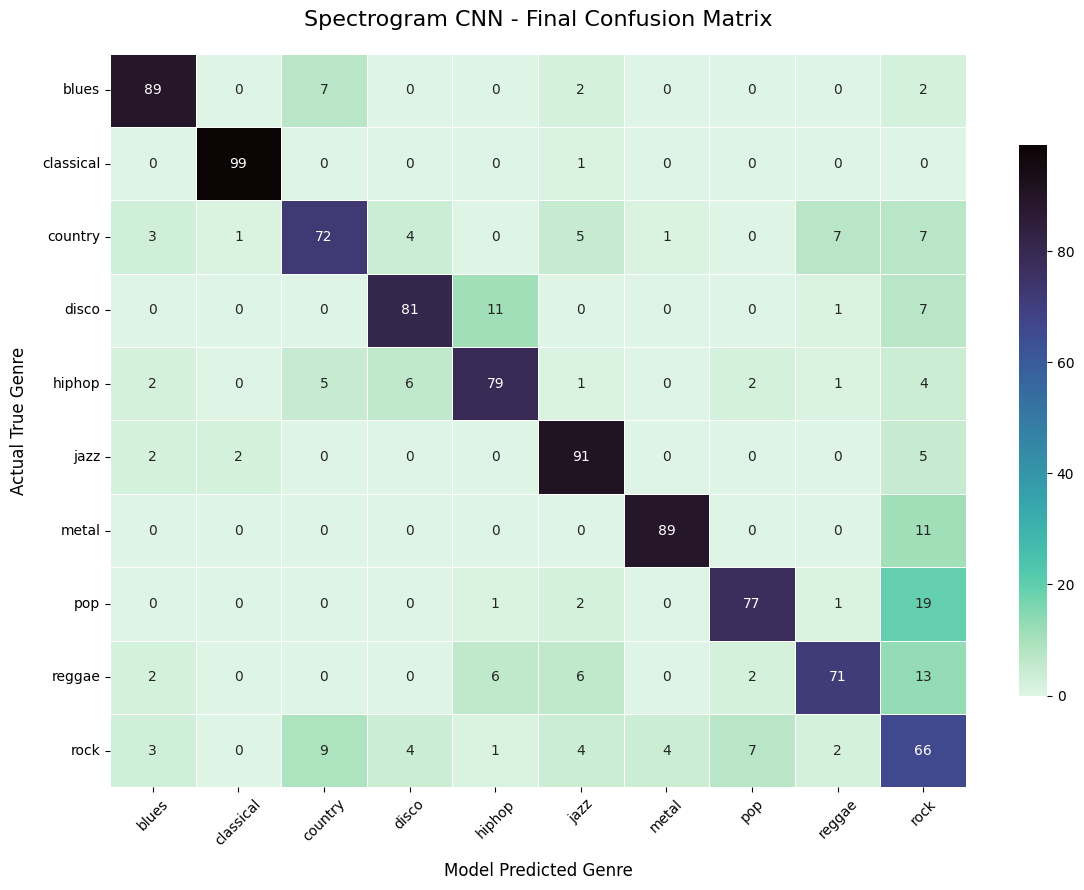

In [15]:
# 1. Load the absolute best weights saved during training
# (This ensures we don't just use the weights from the final epoch if it overfit slightly at the end)
model = SpectroCNN(num_classes=10).to(device)
model.load_state_dict(torch.load('best_spectro_cnn.pth'))
model.eval()

y_true = []
y_pred = []

print("Running inference on the strictly isolated Test Set...")

# Disable gradient tracking for faster inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Get the ordered list of genres for our labels
genres = sorted(os.listdir('gtzan_audio_split/test'))

# ==========================================
# VISUALIZATION 1: CLASSIFICATION REPORT (TABLE)
# ==========================================
print("\n" + "="*50)
print(" FINAL CLASSIFICATION REPORT (TEST SET)")
print("="*50)
# This automatically formats Precision, Recall, and F1 into a clean table
print(classification_report(y_true, y_pred, target_names=genres))

# ==========================================
# VISUALIZATION 2: CONFUSION MATRIX (HEATMAP)
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
# Using a custom color map (mako) that looks incredibly clean and professional
sns.heatmap(cm, annot=True, fmt='d', cmap='mako_r',
            xticklabels=genres, yticklabels=genres,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Spectrogram CNN - Final Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual True Genre', fontsize=12, labelpad=10)
plt.xlabel('Model Predicted Genre', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

print("\nGenerating Confusion Matrix Graphic...")
plt.show()

## ResNet Only

Running inference on the strictly isolated Test Set...

 FINAL CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

       blues       0.84      0.88      0.86       100
   classical       0.95      0.98      0.97       100
     country       0.72      0.88      0.79       100
       disco       0.89      0.81      0.85       100
      hiphop       0.83      0.85      0.84       100
        jazz       0.94      0.88      0.91       100
       metal       0.97      0.88      0.92       100
         pop       0.77      0.76      0.76       100
      reggae       0.91      0.68      0.78       100
        rock       0.54      0.63      0.58       100

    accuracy                           0.82      1000
   macro avg       0.83      0.82      0.83      1000
weighted avg       0.83      0.82      0.83      1000


Generating Confusion Matrix Graphic...


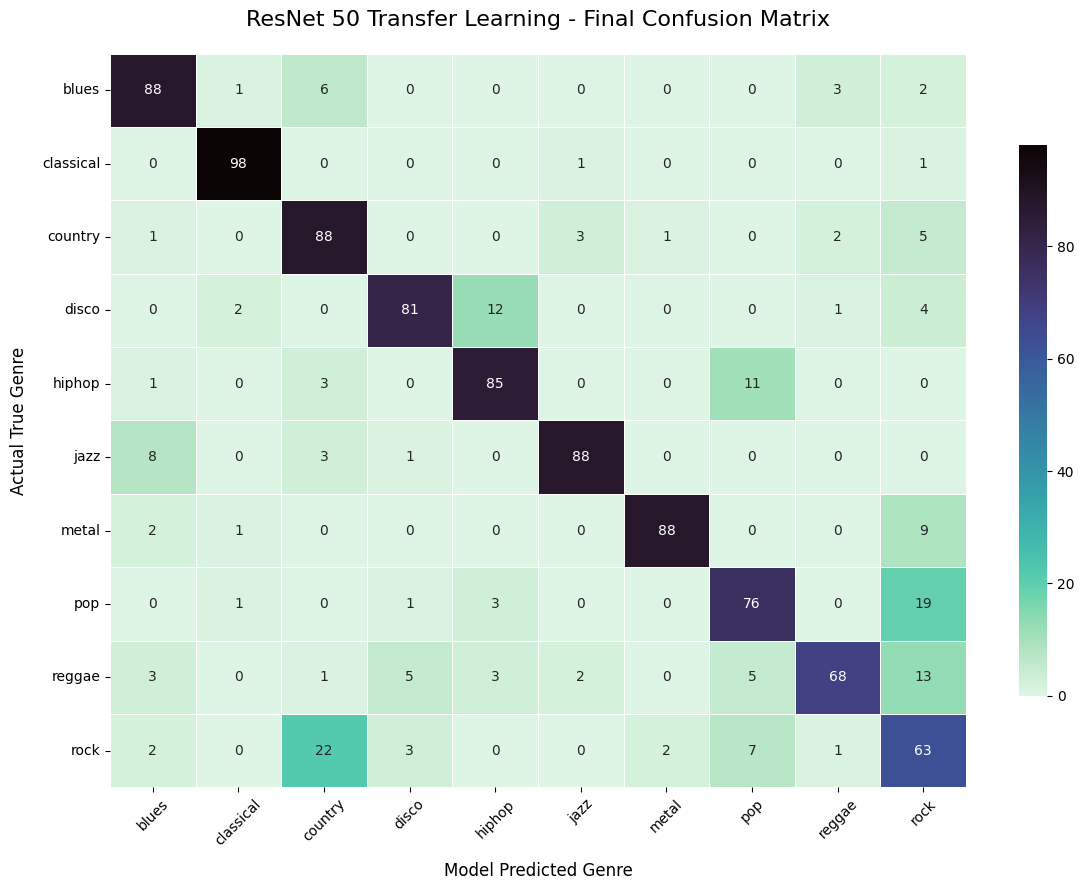

In [16]:
# 1. Load the absolute best weights saved during training
# (This ensures we don't just use the weights from the final epoch if it overfit slightly at the end)
model = SpectroResNet50(num_classes=10).to(device)
model.load_state_dict(torch.load('best_resnet50.pth'))
model.eval()

y_true = []
y_pred = []

print("Running inference on the strictly isolated Test Set...")

# Disable gradient tracking for faster inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Get the ordered list of genres for our labels
genres = sorted(os.listdir('gtzan_audio_split/test'))

# ==========================================
# VISUALIZATION 1: CLASSIFICATION REPORT (TABLE)
# ==========================================
print("\n" + "="*50)
print(" FINAL CLASSIFICATION REPORT (TEST SET)")
print("="*50)
# This automatically formats Precision, Recall, and F1 into a clean table
print(classification_report(y_true, y_pred, target_names=genres))

# ==========================================
# VISUALIZATION 2: CONFUSION MATRIX (HEATMAP)
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
# Using a custom color map (mako) that looks incredibly clean and professional
sns.heatmap(cm, annot=True, fmt='d', cmap='mako_r',
            xticklabels=genres, yticklabels=genres,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('ResNet 50 Transfer Learning - Final Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual True Genre', fontsize=12, labelpad=10)
plt.xlabel('Model Predicted Genre', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

print("\nGenerating Confusion Matrix Graphic...")
plt.show()

## Soft Ensemble

Loading optimized weights into the Ensemble...
Running Inference on Isolated Test Set...

ENSEMBLE CLASSIFICATION REPORT
              precision    recall  f1-score   support

       blues       0.86      0.92      0.89       100
   classical       0.96      0.99      0.98       100
     country       0.75      0.85      0.79       100
       disco       0.92      0.86      0.89       100
      hiphop       0.86      0.87      0.87       100
        jazz       0.88      0.89      0.89       100
       metal       0.98      0.89      0.93       100
         pop       0.82      0.79      0.81       100
      reggae       0.97      0.73      0.83       100
        rock       0.55      0.65      0.59       100

    accuracy                           0.84      1000
   macro avg       0.86      0.84      0.85      1000
weighted avg       0.86      0.84      0.85      1000



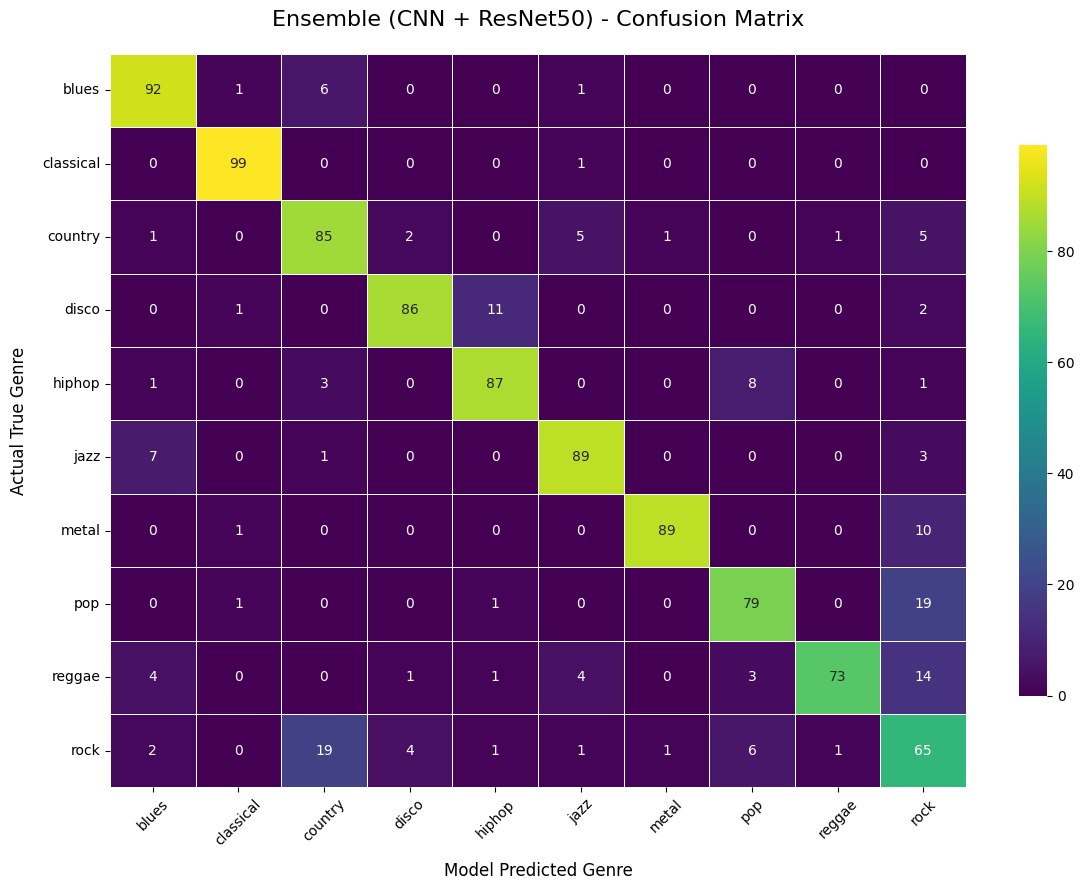

In [17]:
class UltimateEnsemble(nn.Module):
    def __init__(self, model_a, model_b):
        super(UltimateEnsemble, self).__init__()
        self.model_a = model_a
        self.model_b = model_b
    def forward(self, x):
        prob_a = F.softmax(self.model_a(x), dim=1)
        prob_b = F.softmax(self.model_b(x), dim=1)
        return (prob_a + prob_b) / 2.0

print("Loading optimized weights into the Ensemble...")
expert_cnn = SpectroCNN(num_classes=10).to(device)
expert_cnn.load_state_dict(torch.load('best_spectro_cnn.pth'))
expert_cnn.eval()

expert_resnet = SpectroResNet50(num_classes=10).to(device)
expert_resnet.load_state_dict(torch.load('best_resnet50.pth'))
expert_resnet.eval()

ultimate_model = UltimateEnsemble(expert_cnn, expert_resnet).to(device)
ultimate_model.eval()

y_true = []
y_pred = []

print("Running Inference on Isolated Test Set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = ultimate_model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

genres = sorted(os.listdir('gtzan_audio_split/test'))

print("\n" + "="*50)
print("ENSEMBLE CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=genres))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=genres, yticklabels=genres,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Ensemble (CNN + ResNet50) - Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual True Genre', fontsize=12, labelpad=10)
plt.xlabel('Model Predicted Genre', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Weighted Ensemble

Loading optimized weights into the Experts...

Extracting predictions from the Validation Set...
Training the Logistic Regression Meta-Classifier...
Meta-Classifier successfully learned the experts' strengths and weaknesses!

Extracting predictions from the strictly isolated Test Set...
Running Meta-Inference...

 WEIGHTED ENSEMBLE (META-CLASSIFIER) REPORT
              precision    recall  f1-score   support

       blues       0.87      0.88      0.88       100
   classical       0.97      0.99      0.98       100
     country       0.79      0.78      0.78       100
       disco       0.88      0.82      0.85       100
      hiphop       0.88      0.81      0.84       100
        jazz       0.88      0.88      0.88       100
       metal       0.98      0.89      0.93       100
         pop       0.84      0.79      0.81       100
      reggae       0.80      0.74      0.77       100
        rock       0.54      0.74      0.63       100

    accuracy                           0.83  

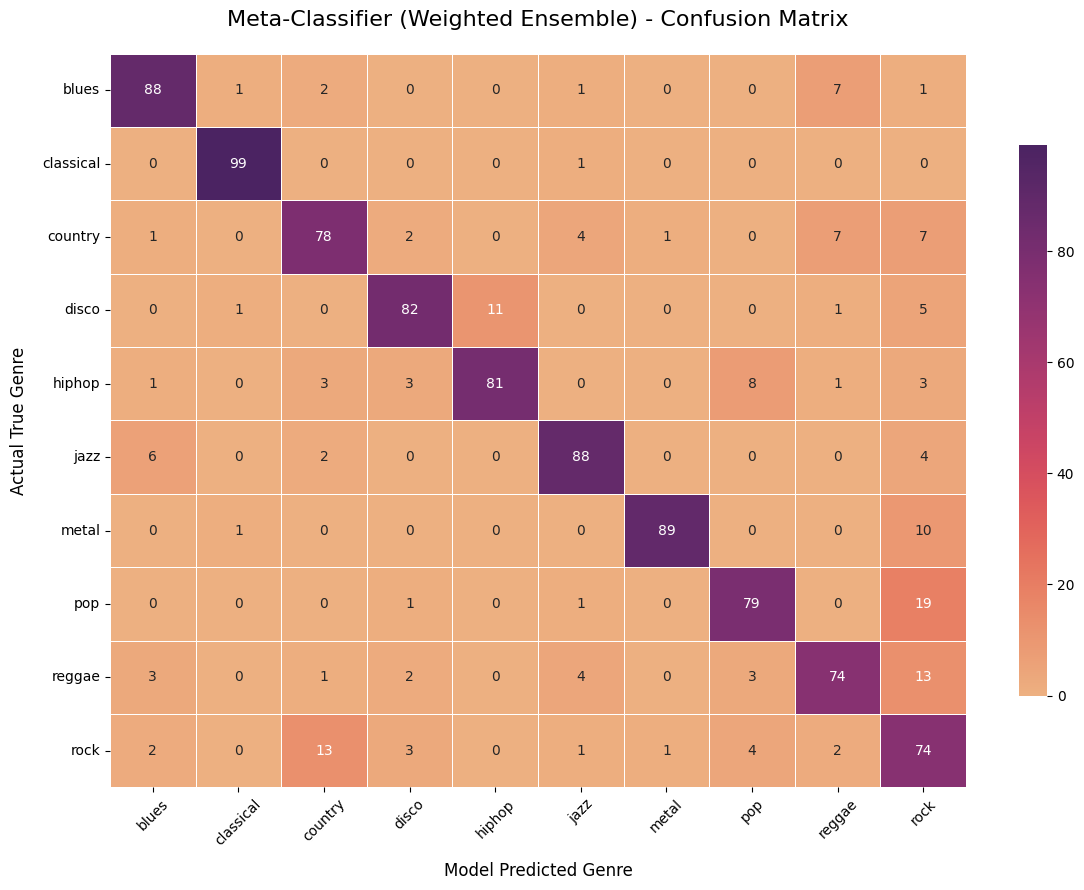

In [18]:
print("Loading optimized weights into the Experts...")
expert_cnn = SpectroCNN(num_classes=10).to(device)
expert_cnn.load_state_dict(torch.load('best_spectro_cnn.pth'))
expert_cnn.eval()

expert_resnet = SpectroResNet50(num_classes=10).to(device)
expert_resnet.load_state_dict(torch.load('best_resnet50.pth'))
expert_resnet.eval()

# Helper function to extract predictions
def get_expert_predictions(dataloader):
    cnn_probs_list, resnet_probs_list, true_labels_list = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            # Get raw logits and convert to probabilities
            prob_cnn = F.softmax(expert_cnn(inputs), dim=1).cpu().numpy()
            prob_resnet = F.softmax(expert_resnet(inputs), dim=1).cpu().numpy()

            cnn_probs_list.append(prob_cnn)
            resnet_probs_list.append(prob_resnet)
            true_labels_list.extend(labels.numpy())

    # Combine predictions: 10 features from CNN + 10 features from ResNet = 20 features total
    X_combined = np.hstack((np.vstack(cnn_probs_list), np.vstack(resnet_probs_list)))
    y_true = np.array(true_labels_list)
    return X_combined, y_true

# --- STEP A: Train Meta-Classifier on Validation Set ---
print("\nExtracting predictions from the Validation Set...")
X_val, y_val = get_expert_predictions(val_loader)

print("Training the Logistic Regression Meta-Classifier...")
meta_classifier = LogisticRegression(max_iter=1000, random_state=42)
meta_classifier.fit(X_val, y_val)
print("Meta-Classifier successfully learned the experts' strengths and weaknesses!")

# --- STEP B: Evaluate on Test Set ---
print("\nExtracting predictions from the strictly isolated Test Set...")
X_test, y_test = get_expert_predictions(test_loader)

print("Running Meta-Inference...")
y_pred_meta = meta_classifier.predict(X_test)

# --- STEP C: Generate Results ---
genres = sorted(os.listdir('gtzan_audio_split/test'))

print("\n" + "="*50)
print(" WEIGHTED ENSEMBLE (META-CLASSIFIER) REPORT")
print("="*50)
print(classification_report(y_test, y_pred_meta, target_names=genres))

cm_meta = confusion_matrix(y_test, y_pred_meta)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_meta, annot=True, fmt='d', cmap='flare',
            xticklabels=genres, yticklabels=genres,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Meta-Classifier (Weighted Ensemble) - Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual True Genre', fontsize=12, labelpad=10)
plt.xlabel('Model Predicted Genre', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Random Forest

Loading optimized weights into the Experts...

Extracting predictions from the Validation Set...
Training the Random Forest Meta-Classifier...
Random Forest successfully learned the non-linear expert rules!

Extracting predictions from the strictly isolated Test Set...
Running Meta-Inference...

 RANDOM FOREST (META-CLASSIFIER) REPORT
              precision    recall  f1-score   support

       blues       0.86      0.92      0.89       100
   classical       0.93      0.99      0.96       100
     country       0.76      0.80      0.78       100
       disco       0.93      0.79      0.85       100
      hiphop       0.88      0.86      0.87       100
        jazz       0.90      0.89      0.89       100
       metal       0.96      0.87      0.91       100
         pop       0.83      0.77      0.80       100
      reggae       0.86      0.77      0.81       100
        rock       0.50      0.63      0.56       100

    accuracy                           0.83      1000
   macro avg 

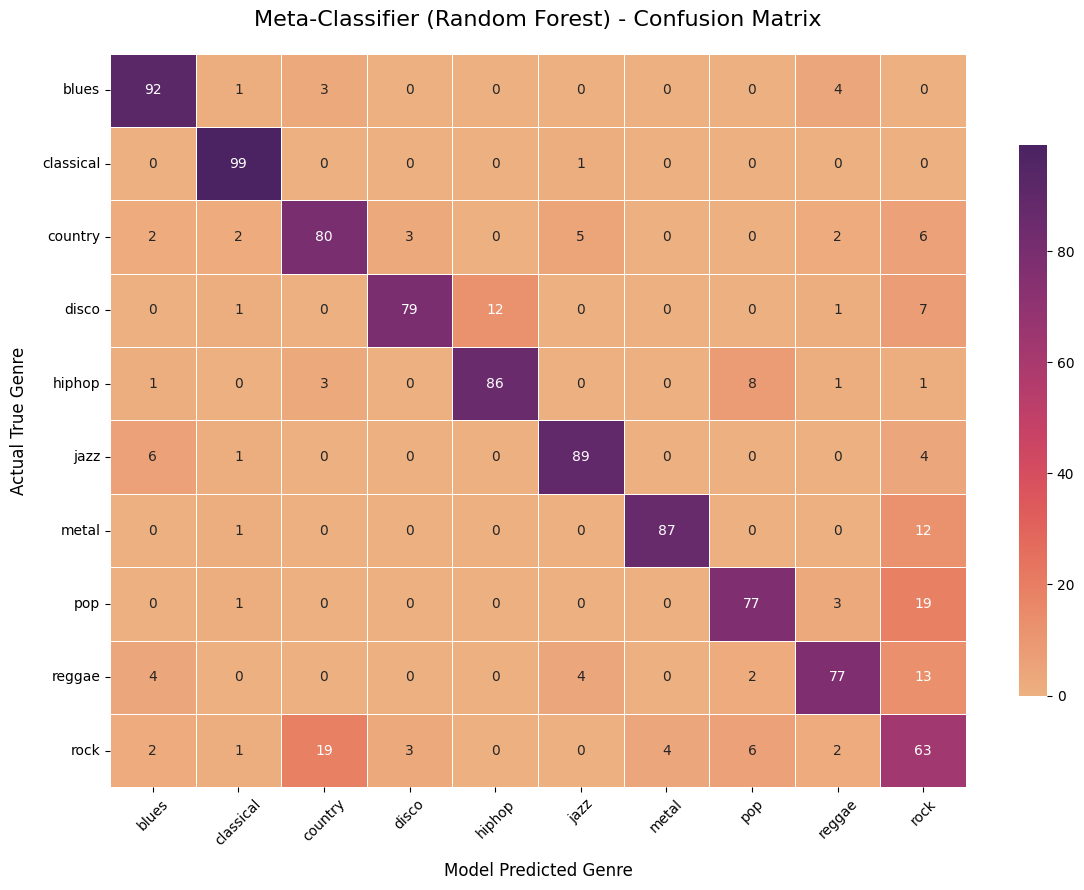

In [19]:
from sklearn.ensemble import RandomForestClassifier

print("Loading optimized weights into the Experts...")
expert_cnn = SpectroCNN(num_classes=10).to(device)
expert_cnn.load_state_dict(torch.load('best_spectro_cnn.pth'))
expert_cnn.eval()

expert_resnet = SpectroResNet50(num_classes=10).to(device)
expert_resnet.load_state_dict(torch.load('best_resnet50.pth'))
expert_resnet.eval()

# --- STEP A: Train the Non-Linear Meta-Classifier ---
print("\nExtracting predictions from the Validation Set...")
X_val, y_val = get_expert_predictions(val_loader)

print("Training the Random Forest Meta-Classifier...")
# We use a Random Forest (100 trees) with a max depth of 5 to prevent overfitting
# on the relatively small validation set.
meta_classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
meta_classifier.fit(X_val, y_val)
print("Random Forest successfully learned the non-linear expert rules!")

# --- STEP B: Evaluate on Test Set ---
print("\nExtracting predictions from the strictly isolated Test Set...")
X_test, y_test = get_expert_predictions(test_loader)

print("Running Meta-Inference...")
y_pred_meta = meta_classifier.predict(X_test)

# --- STEP C: Generate Results ---
genres = sorted(os.listdir('gtzan_audio_split/test'))

print("\n" + "="*50)
print(" RANDOM FOREST (META-CLASSIFIER) REPORT")
print("="*50)
print(classification_report(y_test, y_pred_meta, target_names=genres))

cm_meta = confusion_matrix(y_test, y_pred_meta)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_meta, annot=True, fmt='d', cmap='flare',
            xticklabels=genres, yticklabels=genres,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Meta-Classifier (Random Forest) - Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual True Genre', fontsize=12, labelpad=10)
plt.xlabel('Model Predicted Genre', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Heuristic Router

Running Heuristic Expert Router on Test Set...

 HEURISTIC EXPERT ROUTER REPORT
              precision    recall  f1-score   support

       blues       0.86      0.88      0.87       100
   classical       0.96      0.98      0.97       100
     country       0.72      0.84      0.78       100
       disco       0.92      0.80      0.86       100
      hiphop       0.84      0.85      0.85       100
        jazz       0.94      0.88      0.91       100
       metal       0.94      0.91      0.92       100
         pop       0.78      0.75      0.77       100
      reggae       0.83      0.77      0.80       100
        rock       0.54      0.60      0.57       100

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000


Generating Final Router Confusion Matrix Graphic...


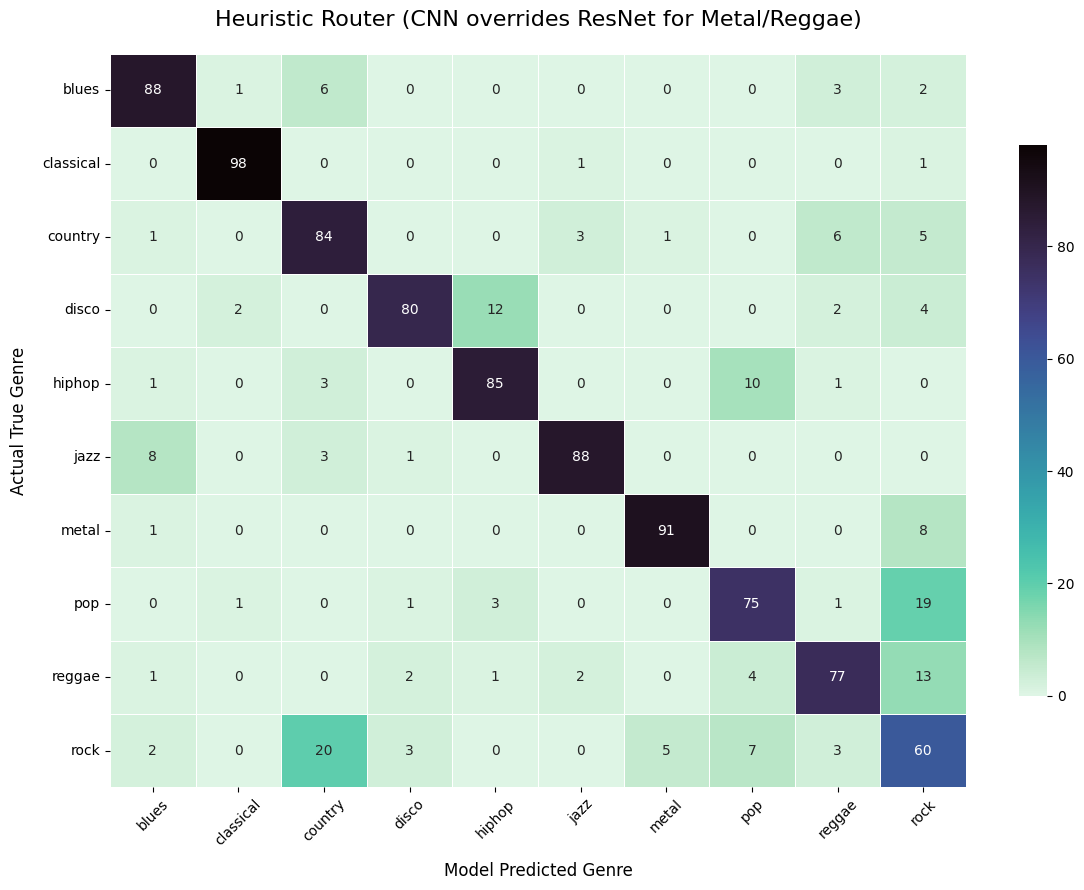

In [20]:
print("Running Heuristic Expert Router on Test Set...")

# Extract Test Set Predictions (Using the function we defined earlier)
X_test, y_test = get_expert_predictions(test_loader)

# Map of GTZAN genres (Alphabetical)
# 0: blues, 1: classical, 2: country, 3: disco, 4: hiphop,
# 5: jazz, 6: metal, 7: pop, 8: reggae, 9: rock

# 1. Define the CNN's specific domains of expertise
cnn_specialties = [6, 8] # Metal (6) and Reggae (8)

y_pred_router = []

# 2. Iterate through every single audio slice
for i in range(len(X_test)):
    # Split the 20 features back into CNN probs and ResNet probs
    prob_cnn = X_test[i, :10]
    prob_resnet = X_test[i, 10:]

    # Get each model's top guess
    pred_cnn = np.argmax(prob_cnn)
    pred_resnet = np.argmax(prob_resnet)

    # --- THE HARDCODED ROUTING LOGIC ---
    # If the CNN predicts a rhythmic specialty (Metal/Reggae) with >50% confidence, trust it!
    if pred_cnn in cnn_specialties and prob_cnn[pred_cnn] > 0.50:
        y_pred_router.append(pred_cnn)
    # Otherwise, default to the deep textural knowledge of the ResNet
    else:
        y_pred_router.append(pred_resnet)

# ==========================================
# GENERATE FINAL RESULTS
# ==========================================
genres = sorted(os.listdir('gtzan_audio_split/test'))

print("\n" + "="*50)
print(" HEURISTIC EXPERT ROUTER REPORT")
print("="*50)
print(classification_report(y_test, y_pred_router, target_names=genres))

cm_router = confusion_matrix(y_test, y_pred_router)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_router, annot=True, fmt='d', cmap='mako_r',
            xticklabels=genres, yticklabels=genres,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Heuristic Router (CNN overrides ResNet for Metal/Reggae)', fontsize=16, pad=20)
plt.ylabel('Actual True Genre', fontsize=12, labelpad=10)
plt.xlabel('Model Predicted Genre', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

print("\nGenerating Final Router Confusion Matrix Graphic...")
plt.show()